In [1]:
import scanpy as sc
import pandas as pd

adata_dr = sc.read_h5ad("stem_cells_only_wholebody_nr4a1_ko.h5ad")

c:\Users\selim\miniconda3\envs\scanpy_env_311\Lib\site-packages\scanpy\_utils\__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
c:\Users\selim\miniconda3\envs\scanpy_env_311\Lib\site-packages\scanpy\__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
c:\Users\selim\miniconda3\envs\scanpy_env_311\Lib\site-packages\scanpy\readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


## Step 1 — Browse available pathway libraries and find your pathway
Use `browse_pathways()` to preview what's available **before** running the pipeline.

In [2]:
adata_dr.layers["counts"] = adata_dr.X.copy()
# Normalizing to median total counts
sc.pp.normalize_total(adata_dr)
# Logarithmize the data
sc.pp.log1p(adata_dr)

adata_dr

AnnData object with n_obs × n_vars = 2817 × 11177
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle', 'SubCellType', 'CellType0', 'Condition', 'BatchID0', 'cell_potency'
    uns: 'log1p'
    layers: 'counts'

c:\Users\selim\miniconda3\envs\scanpy_env_311\Lib\site-packages\scanpy\preprocessing\_pca.py:206: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  Version(ad.__version__) < Version("0.9")
c:\Users\selim\miniconda3\envs\scanpy_env_311\Lib\site-packages\scanpy\neighbors\__init__.py:423: FutureWarning: Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.
  if "X_diffmap" in adata.obsm_keys():
c:\Users\selim\miniconda3\envs\scanpy_env_311\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https:/

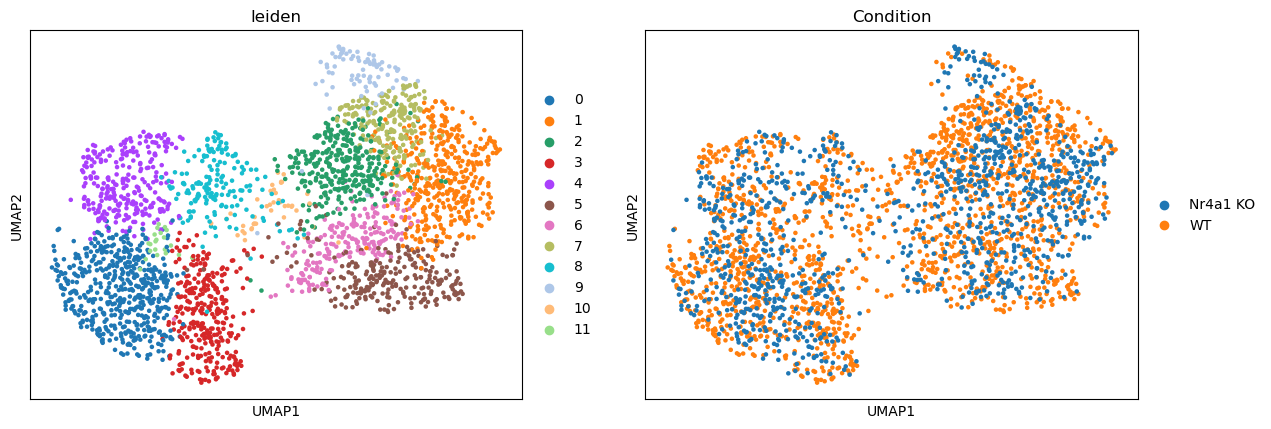

In [3]:
# process to visualize
sc.pp.highly_variable_genes(adata_dr, n_top_genes=2000)
sc.tl.pca(adata_dr, n_comps=50, svd_solver="arpack")
sc.pp.neighbors(adata_dr, n_neighbors=15)
sc.tl.umap(adata_dr, n_components=2)
sc.tl.leiden(adata_dr, flavor="leidenalg", n_iterations=2, resolution=1.0)

# Using the igraph implementation and a fixed number of iterations can be significantly faster,
# especially for larger datasets
sc.pl.umap(adata_dr, color=["leiden", "Condition"])


In [4]:
from qubo_dr.pathway import browse_pathways, preview_pathway_genes, list_enrichr_libraries

# ── List available libraries (filter by keyword) ───────────────────────────
print("=== Libraries containing 'KEGG' ===")
print(list_enrichr_libraries('KEGG'))

print("\n=== Libraries containing 'GO_Biological' ===")
print(list_enrichr_libraries('GO_Biological'))

print("\n=== Libraries containing 'Reactome' ===")
print(list_enrichr_libraries('Reactome'))

print("\n=== Libraries containing 'GO_Molecular_Function' ===")
print(list_enrichr_libraries('GO_Molecular_Function'))

=== Libraries containing 'KEGG' ===
['KEGG_2013', 'KEGG_2015', 'KEGG_2016', 'KEGG_2019_Human', 'KEGG_2019_Mouse', 'KEGG_2021_Human', 'KEGG_2026']

=== Libraries containing 'GO_Biological' ===
['GO_Biological_Process_2021', 'GO_Biological_Process_2023', 'GO_Biological_Process_2025']

=== Libraries containing 'Reactome' ===
['Reactome_2022', 'Reactome_Pathways_2024']

=== Libraries containing 'GO_Molecular_Function' ===
['GO_Molecular_Function_2021', 'GO_Molecular_Function_2023', 'GO_Molecular_Function_2025']


In [5]:
# ── Browse via Enrichr libraries (offline, no rate limit) ─────────────────
browse_pathways('Wnt', organism='human', libraries=['KEGG_2026', 'GO_Biological_Process_2025'], 
                show_genes=True, max_results=20)


[KEGG_2026  —  matches for 'Wnt']
  [ 170 genes]  WNT SIGNALING PATHWAY
             → RNF43, TLE4, RYK, TLE3, TLE2, FBXW11, TLE1, APCDD1L, CTNNBIP1, TPTEP2-CSNK1E ...

[GO_Biological_Process_2025  —  matches for 'Wnt']
  [  83 genes]  Wnt Signaling Pathway (GO:0016055)
             → NCOA3, CSNK1A1, RYK, JUP, WNT5A, CAV1, WNT5B, AXIN2, WNT9A, WNT9B ...
  [  27 genes]  Wnt Signaling Pathway, Planar Cell Polarity Pathway (GO:0060071)
             → FZD2, MAGI2, RHOA, RYK, FZD6, SMURF2, SMURF1, WNT5A, FZD7, WNT7A ...
  [  63 genes]  Canonical Wnt Signaling Pathway (GO:0060070)
             → RYK, JUP, WNT5A, CAV1, WNT5B, AXIN2, WNT9A, WNT9B, WNT16, SFRP4 ...
  [ 146 genes]  Negative Regulation of Wnt Signaling Pathway (GO:0030178)
             → RNF43, TLE5, TLE4, TLE3, TLE2, TLE1, CTNNBIP1, WNT5A, SHISA6, AMFR ...
  [ 117 genes]  Negative Regulation of Canonical Wnt Signaling Pathway (GO:0090090)
             → TLE5, TLE4, TLE3, TLE2, TLE1, WNT5A, SHISA6, AMFR, SOX13, DKK1 ...
  [  43 

{'KEGG_2026': {'WNT SIGNALING PATHWAY': ['RNF43',
   'TLE4',
   'RYK',
   'TLE3',
   'TLE2',
   'FBXW11',
   'TLE1',
   'APCDD1L',
   'CTNNBIP1',
   'TPTEP2-CSNK1E',
   'WNT5A',
   'WNT5B',
   'DKK1',
   'DKK2',
   'RBX1',
   'TLE7',
   'DKK4',
   'TLE6',
   'SFRP4',
   'SFRP5',
   'SFRP2',
   'TBL1XR1',
   'MAPK10',
   'BAMBI',
   'TP53',
   'LEF1',
   'ROCK2',
   'CTNND2',
   'LRP6',
   'LRP5',
   'FZD10',
   'APCDD1',
   'NKD1',
   'SFRP1',
   'NKD2',
   'CCAR2',
   'RUVBL1',
   'FRAT1',
   'FRAT2',
   'FRZB',
   'CCND3',
   'CCND2',
   'WIF1',
   'CCND1',
   'MYC',
   'GPC4',
   'SERPINF1',
   'CCN4',
   'TBL1X',
   'TBL1Y',
   'MAP3K7',
   'BTRC',
   'LZTS2',
   'CER1',
   'FZD2',
   'SIAH1',
   'SMAD3',
   'CREBBP',
   'FZD1',
   'PRKCG',
   'FZD4',
   'WNT10B',
   'SMAD4',
   'WNT10A',
   'FZD6',
   'WNT3A',
   'FZD5',
   'FZD8',
   'FZD7',
   'FZD9',
   'CSNK1E',
   'PRKCB',
   'PRKCA',
   'CCDC88C',
   'PROC',
   'VANGL2',
   'FOSL1',
   'VANGL1',
   'CSNK2B',
   'TCF7',
   'W

In [6]:
# ── Preview the full gene list for a specific pathway ─────────────────────
wnt_genes = preview_pathway_genes('Canonical Wnt Signaling Pathway (GO:0060070)', organism='human', library='GO_Biological_Process_2025')
print(f"\nTotal: {len(wnt_genes)} genes")

  Found 'Canonical Wnt Signaling Pathway (GO:0060070)'
  Library: [GO_Biological_Process_2025]  |  Genes: 63

[GO_Biological_Process_2025  —  'Canonical Wnt Signaling Pathway (GO:0060070)']  63 genes:
  RYK         JUP         WNT5A       CAV1        WNT5B       AXIN2     
  WNT9A       WNT9B       WNT16       SFRP4       SFRP5       BCL9      
  SFRP2       LEF1        GSK3B       LRRK2       LRP6        WNT8B     
  LRP5        FZD10       WNT8A       SFRP1       WNT6        FRAT1     
  FRAT2       FRZB        WNT11       DVL1        DVL2        DVL3      
  WNT1        WNT2        WNT3        WNT4        FZD2        SIAH1     
  FZD1        FZD4        TCF7L2      WNT10B      TCF7L1      WNT10A    
  FZD6        WNT3A       FZD5        FZD8        FZD7        SIAH2     
  WNT7A       FZD9        WNT7B       CSNK1E      SMAD7       NR4A2     
  TCF7        SNAI1       RAB5A       WNT2B       RARG        CTNNB1    
  DIXDC1      GATA3       BCL9L     

Total: 63 genes


In [7]:
# ── Preview the full gene list for a specific pathway ─────────────────────
wnt_genes = preview_pathway_genes('WNT SIGNALING PATHWAY', organism='human', library='KEGG_2026')
print(f"\nTotal: {len(wnt_genes)} genes")

  Found 'WNT SIGNALING PATHWAY'
  Library: [KEGG_2026]  |  Genes: 170

[KEGG_2026  —  'WNT SIGNALING PATHWAY']  170 genes:
  RNF43       TLE4        RYK         TLE3        TLE2        FBXW11    
  TLE1        APCDD1L     CTNNBIP1    TPTEP2-CSNK1E  WNT5A       WNT5B     
  DKK1        DKK2        RBX1        TLE7        DKK4        TLE6      
  SFRP4       SFRP5       SFRP2       TBL1XR1     MAPK10      BAMBI     
  TP53        LEF1        ROCK2       CTNND2      LRP6        LRP5      
  FZD10       APCDD1      NKD1        SFRP1       NKD2        CCAR2     
  RUVBL1      FRAT1       FRAT2       FRZB        CCND3       CCND2     
  WIF1        CCND1       MYC         GPC4        SERPINF1    CCN4      
  TBL1X       TBL1Y       MAP3K7      BTRC        LZTS2       CER1      
  FZD2        SIAH1       SMAD3       CREBBP      FZD1        PRKCG     
  FZD4        WNT10B      SMAD4       WNT10A      FZD6        WNT3A     
  FZD5        FZD8        FZD7        FZD9        CSNK1E      PRKCB    

In [8]:
from pprint import pprint
pprint(wnt_genes, compact=True, width=177)

['RNF43', 'TLE4', 'RYK', 'TLE3', 'TLE2', 'FBXW11', 'TLE1', 'APCDD1L', 'CTNNBIP1', 'TPTEP2-CSNK1E', 'WNT5A', 'WNT5B', 'DKK1', 'DKK2', 'RBX1', 'TLE7', 'DKK4', 'TLE6', 'SFRP4',
 'SFRP5', 'SFRP2', 'TBL1XR1', 'MAPK10', 'BAMBI', 'TP53', 'LEF1', 'ROCK2', 'CTNND2', 'LRP6', 'LRP5', 'FZD10', 'APCDD1', 'NKD1', 'SFRP1', 'NKD2', 'CCAR2', 'RUVBL1', 'FRAT1',
 'FRAT2', 'FRZB', 'CCND3', 'CCND2', 'WIF1', 'CCND1', 'MYC', 'GPC4', 'SERPINF1', 'CCN4', 'TBL1X', 'TBL1Y', 'MAP3K7', 'BTRC', 'LZTS2', 'CER1', 'FZD2', 'SIAH1', 'SMAD3', 'CREBBP',
 'FZD1', 'PRKCG', 'FZD4', 'WNT10B', 'SMAD4', 'WNT10A', 'FZD6', 'WNT3A', 'FZD5', 'FZD8', 'FZD7', 'FZD9', 'CSNK1E', 'PRKCB', 'PRKCA', 'CCDC88C', 'PROC', 'VANGL2', 'FOSL1',
 'VANGL1', 'CSNK2B', 'TCF7', 'WNT2B', 'CTBP2', 'CTBP1', 'CUL1', 'PSEN1', 'NLK', 'RORA', 'PORCN', 'PPP3R1', 'PRKACG', 'PPP3R2', 'SOX17', 'PRKACB', 'SKP1', 'NCOA3', 'RHOA',
 'CSNK1A1', 'MMP7', 'JUN', 'AXIN2', 'NFATC4', 'AXIN1', 'NFATC3', 'NFATC2', 'WNT9A', 'NFATC1', 'WNT9B', 'SIRT1', 'MCC', 'SENP2', 'WNT16',

## Step 2 — Run DR-QUBO on Kong2023 (Crohn's disease) stem cells

In [9]:
adata_dr

AnnData object with n_obs × n_vars = 2817 × 11177
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle', 'SubCellType', 'CellType0', 'Condition', 'BatchID0', 'cell_potency', 'leiden'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'Condition_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [10]:
import numpy as np
from scipy.sparse import issparse
from qubo_dr.pipeline import run_pipeline
from qubo_dr.pathway import preview_pathway_genes

# Extract matrix and gene symbols
# Note: var_names in this dataset are Ensembl IDs — use var['gene_symbols'] for pathway matching
# For datasets where var_names ARE already gene symbols, use: g_cd = list(adata_dr.var_names)
X_cd     = adata_dr.X.toarray().T if issparse(adata_dr.X) else adata_dr.X.T  # → genes × cells
g_cd     = list(adata_dr.var_names)
batch_cd = adata_dr.obs['Condition'].values  

print(f"Wholebody KO — Nr4a1 KO: {(batch_cd == 'Nr4a1 KO').sum()} | WT control: {(batch_cd == 'WT').sum()}")
print(f"Matrix shape (genes × cells): {X_cd.shape}")
print(f"Gene name example: {g_cd[:5]}")

# ── Sanity check: pathway gene overlap before running ─────────────────────
wnt_genes = preview_pathway_genes('WNT SIGNALING PATHWAY', library='KEGG_2026')
overlap   = set(g.upper() for g in g_cd) & set(w.upper() for w in wnt_genes)
print(f"\nWnt genes found in data: {len(overlap)}/{len(wnt_genes)}")
print(f"Example: {sorted(overlap)[:8]}")

Wholebody KO — Nr4a1 KO: 1111 | WT control: 1706
Matrix shape (genes × cells): (11177, 2817)
Gene name example: ['Xkr4', 'Lypla1', 'Tcea1', 'Atp6v1h', 'Rb1cc1']
  Found 'WNT SIGNALING PATHWAY'
  Library: [KEGG_2026]  |  Genes: 170

[KEGG_2026  —  'WNT SIGNALING PATHWAY']  170 genes:
  RNF43       TLE4        RYK         TLE3        TLE2        FBXW11    
  TLE1        APCDD1L     CTNNBIP1    TPTEP2-CSNK1E  WNT5A       WNT5B     
  DKK1        DKK2        RBX1        TLE7        DKK4        TLE6      
  SFRP4       SFRP5       SFRP2       TBL1XR1     MAPK10      BAMBI     
  TP53        LEF1        ROCK2       CTNND2      LRP6        LRP5      
  FZD10       APCDD1      NKD1        SFRP1       NKD2        CCAR2     
  RUVBL1      FRAT1       FRAT2       FRZB        CCND3       CCND2     
  WIF1        CCND1       MYC         GPC4        SERPINF1    CCN4      
  TBL1X       TBL1Y       MAP3K7      BTRC        LZTS2       CER1      
  FZD2        SIAH1       SMAD3       CREBBP      FZD1  

Fetching pathway 'WNT SIGNALING PATHWAY' [KEGG_2026]
  Found 'WNT SIGNALING PATHWAY'
  Library: [KEGG_2026]  |  Genes: 170
  170 genes retrieved
  Appending 3 extra genes: ['Nr4a1', 'Nr4a2', 'Nr4a3']
Pathway genes in data: 110/170  |  extra genes: 2/3
Partitioning: 'Nr4a1 KO' (test/A) vs 'WT' (reference/B)
  Test (A): 1111 cells | Reference (B): 1706 cells
Computing cosine similarity matrices...
Computing differential co-expression (dS = S_ref − S_test)...
  V_diff term: disabled (no cell-state scalar provided)
Building MNN adjacency matrices (SVD d=50)...
Building pathway membership prior (X_net)  [170 pathway + 3 extra genes]...
Assembling QUBO matrix...
  Penalty (spectral): ||Q1||_2=133.6695 → P=267.3391 (scale=2)
QUBO assembled: 112×112 | penalty P=267.3391 | K=20
  [forced_genes] WARNING: ['Nr4a3'] not found in pathway gene set — skipped.
  [forced_genes] Pinning 2 gene(s) to hub: ['Nr4a2', 'Nr4a1']
Solving reduced QUBO (SteepestDescent (classical), 1000 reads) | 110 free genes →

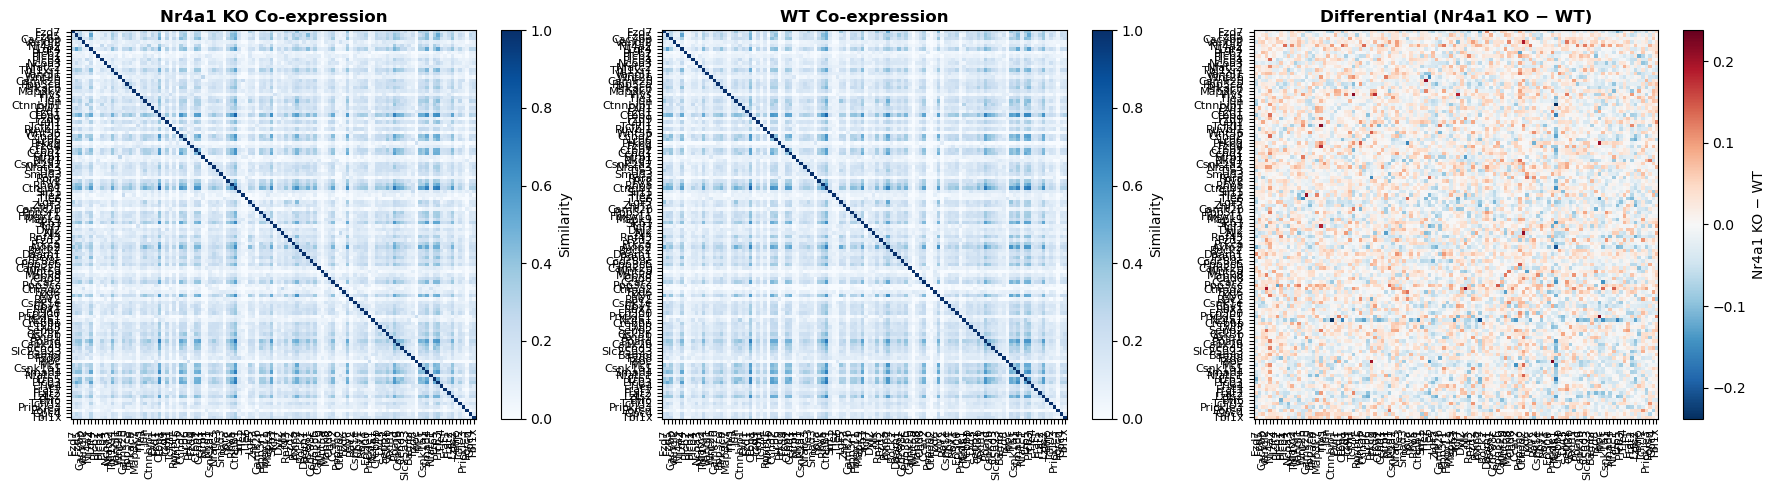

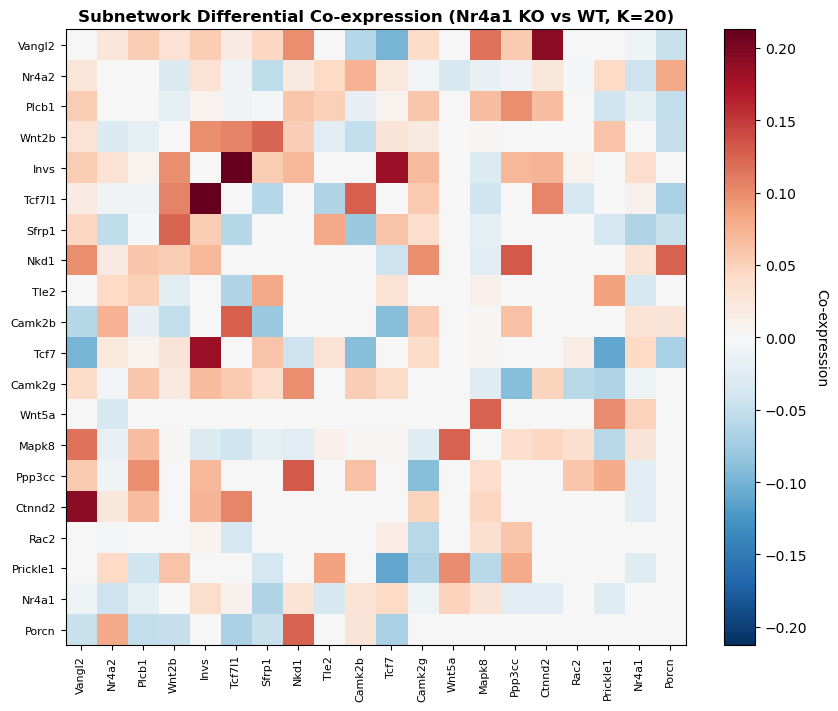

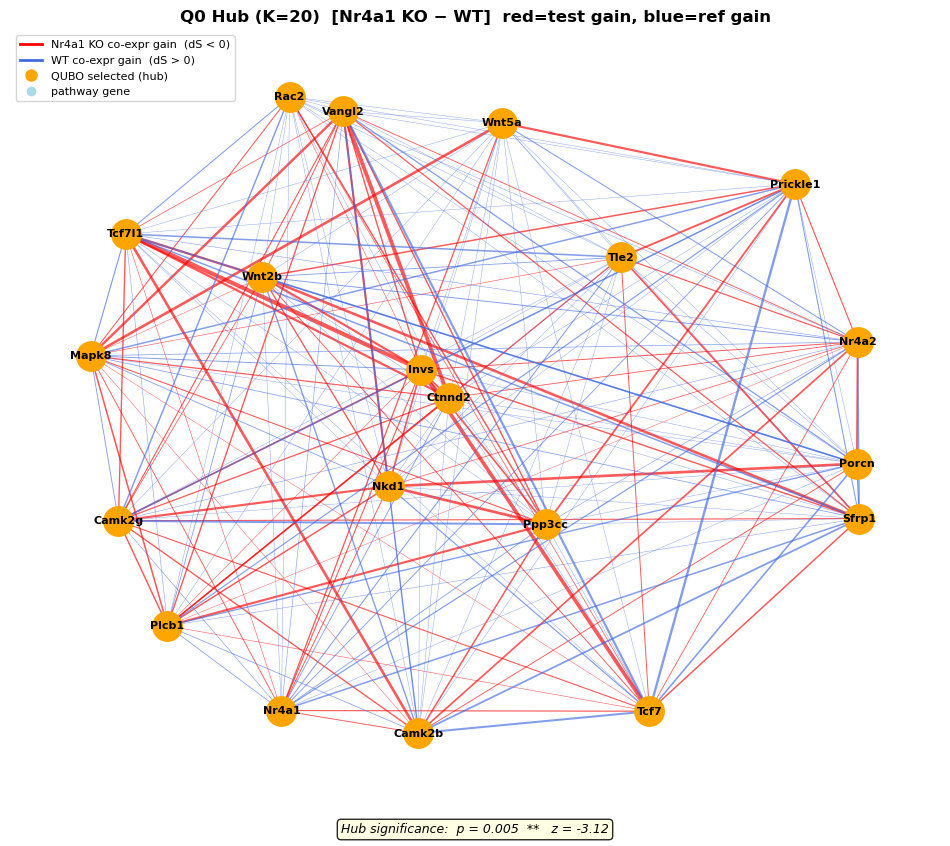

In [16]:
# ── Run DR-QUBO — Kong2023 CD — Wnt signaling ─────────────────────────────
results_cd = run_pipeline(
    X               = X_cd,
    g               = g_cd,
    batch_id        = batch_cd,
    extra_genes     = list(['Nr4a1', "Nr4a2", "Nr4a3"]), 
    forced_genes    = list(['Nr4a1', "Nr4a2", "Nr4a3"]),
    test_label      = 'Nr4a1 KO',      # condition A
    reference_label = 'WT',      # condition B (reference)
    pathway_name    = 'WNT SIGNALING PATHWAY',
    library         = 'KEGG_2026',    # optional: restricts search to one library (faster)
    K               = 20,
    num_reads       = 1000,
    solver          = 'sd',
    plotit          = True,
    outfile         = 'qubo_genes_wholebody_wnt.txt',
)

print("\n── Wholebody KO — selected Wnt subnetwork ──")
print(results_cd['sub_g_net'])

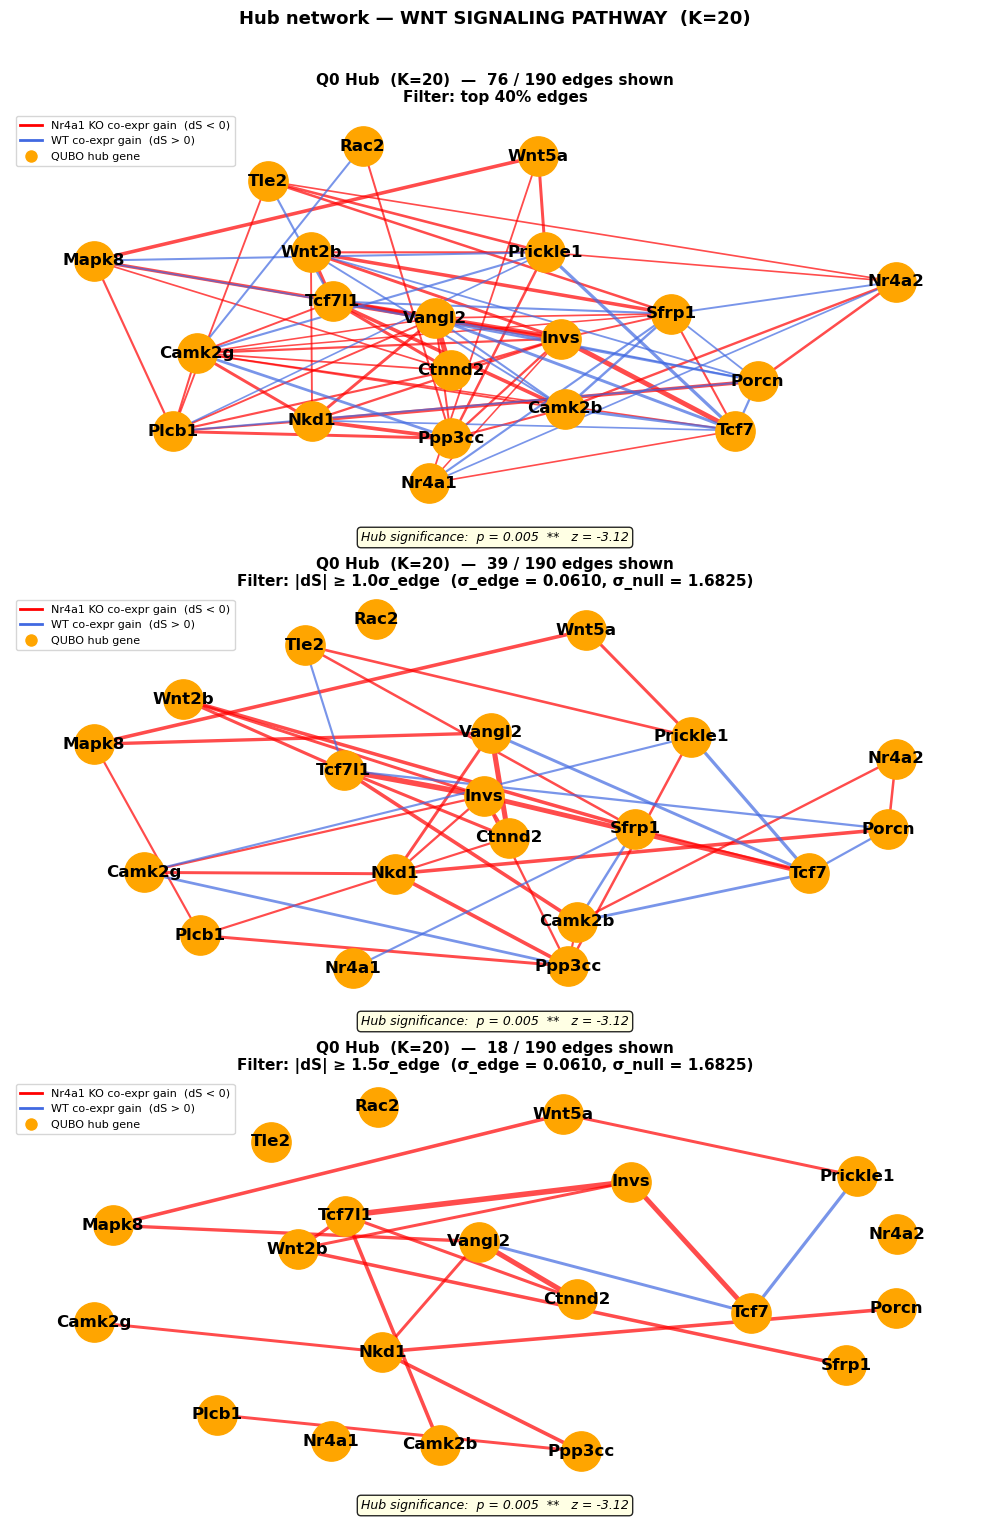

In [17]:
from qubo_dr.plot import plot_hub_network
import matplotlib.pyplot as plt
K = 20
REFERENCE_LABEL = 'WT'      # condition B (reference)
TEST_LABEL = 'Nr4a1 KO'
PATHWAY_NAME = 'WNT SIGNALING PATHWAY'
# ── Three panels: coarse → stat-informed → fine ──────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# Panel 1 — top 40 % of hub edges (quick overview)
plot_hub_network(
    results_cd, top_pct=40,
    test_label=TEST_LABEL, reference_label=REFERENCE_LABEL,
    ax=axes[0]
)

# Panel 2 — statistically principled: edges above 1 null-noise σ
#   σ_edge = std(E_null) / (2 × √(K×(K−1)/2))
#   Requires run_perm_test=True in run_pipeline() (already done above)
plot_hub_network(
    results_cd, n_sigma=1.0,
    test_label=TEST_LABEL, reference_label=REFERENCE_LABEL,
    ax=axes[1]
)

# Panel 3 — stricter: 1.5 σ (fewer, strongest edges only)
plot_hub_network(
    results_cd, n_sigma=1.5,
    test_label=TEST_LABEL, reference_label=REFERENCE_LABEL,
    ax=axes[2]
)

plt.suptitle(f'Hub network — {PATHWAY_NAME}  (K={K})',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


Fetching pathway 'WNT SIGNALING PATHWAY' [KEGG_2026]
  Found 'WNT SIGNALING PATHWAY'
  Library: [KEGG_2026]  |  Genes: 170
Classical baseline  |  method='rowsum'  |  K=20
Pathway genes in data: 110/170
Partitioning: 'Nr4a1 KO' (A) vs 'WT' (B)
  A: 1111 cells | B: 1706 cells
  Selected 20 genes (target K=20)
  Genes: ['Vangl2', 'Camk2d', 'Map3k7', 'Invs', 'Fzd1', 'Cul1', 'Fzd4', 'Csnk2a2', 'Smad3', 'Rhoa', 'Mapk9', 'Daam1', 'Chd8', 'Ppp3cc', 'Ctnnd2', 'Prickle1', 'Senp2', 'Axin1', 'Gpc4', 'Tbl1x']
  Saved 20 genes to classical_genes_CD_wnt.txt
Hub significance test (200 permutations)...
  Hub permutation test: 200 perms, K=20 genes, N=2817 cells…
  E_real=-10.4577  null: mean=0.2935, std=2.1769
  z=-4.94  p=0.0000  ***
Generating plots...
Classical pipeline complete.
QUBO only    (15): ['Camk2b', 'Camk2g', 'Mapk8', 'Nkd1', 'Nr4a1', 'Nr4a2', 'Plcb1', 'Porcn', 'Rac2', 'Sfrp1', 'Tcf7', 'Tcf7l1', 'Tle2', 'Wnt2b', 'Wnt5a']
Classical only (15): ['Axin1', 'Camk2d', 'Chd8', 'Csnk2a2', 'Cul1', '

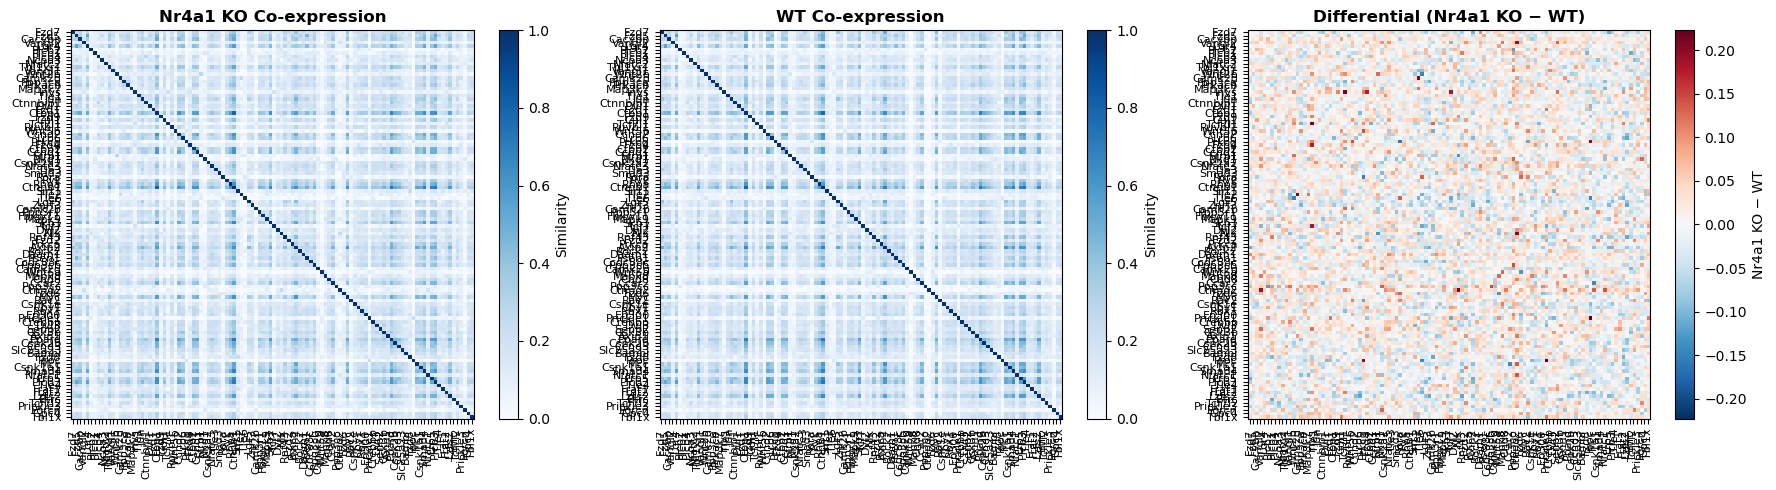

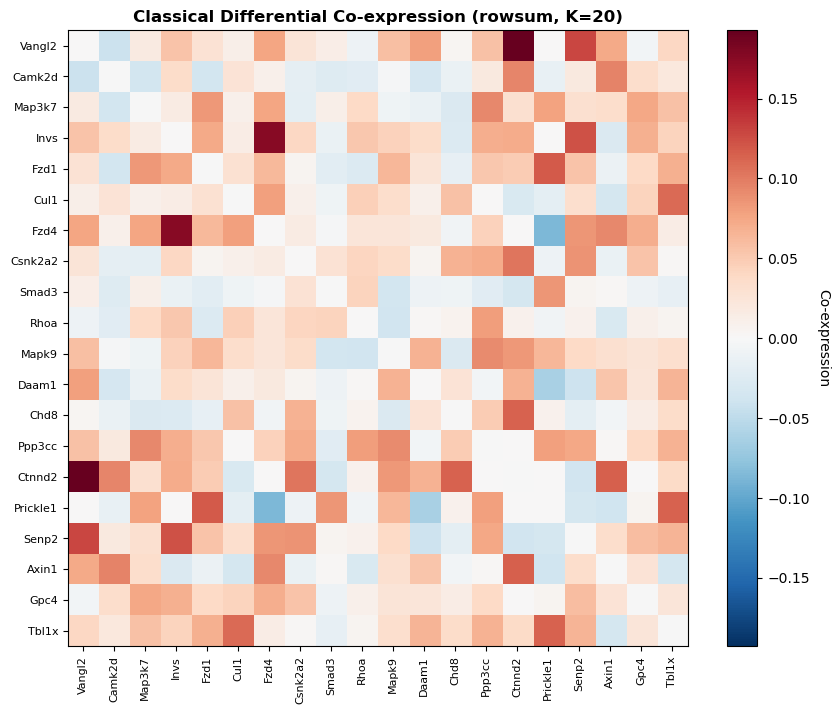

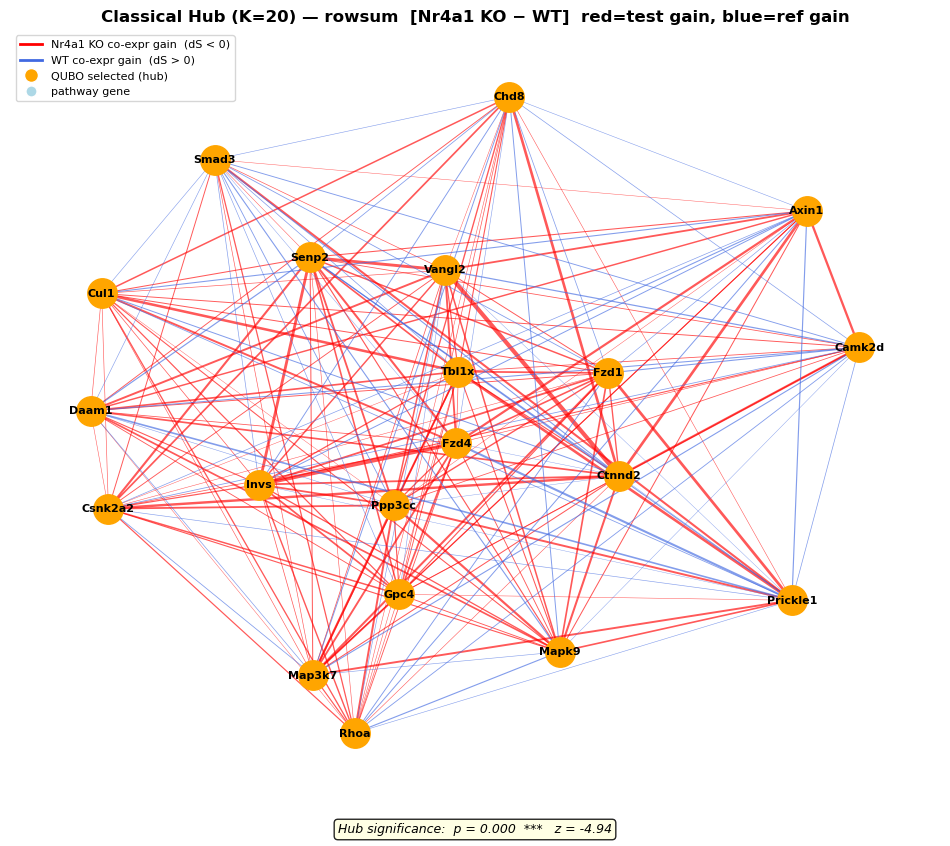

In [18]:
from qubo_dr.pipeline import run_pipeline_classical

# ── Classical baseline — same data, no QUBO ───────────────────────────────
results_cd_classical = run_pipeline_classical(
    X               = X_cd,
    g               = g_cd,
    batch_id        = batch_cd,
    #extra_genes     = list(['Nr4a1', "Nr4a2", "Nr4a3"]), 
    test_label      = 'Nr4a1 KO',      # condition A
    reference_label = 'WT',      # condition B (reference)
    pathway_name    = 'WNT SIGNALING PATHWAY',
    library         = 'KEGG_2026',    # optional: restricts search to one library (faster)
    K               = 20,
    method          = 'rowsum',     # or 'absrowsum' or 'spectral'
    plotit          = True,
    outfile         = 'classical_genes_CD_wnt.txt',
)

# ── Direct comparison ─────────────────────────────────────────────────────
qubo_genes      = set(results_cd['sub_g_net'])
classical_genes = set(results_cd_classical['sub_g_net'])

print(f"QUBO only    ({len(qubo_genes - classical_genes)}): {sorted(qubo_genes - classical_genes)}")
print(f"Classical only ({len(classical_genes - qubo_genes)}): {sorted(classical_genes - qubo_genes)}")
print(f"Shared       ({len(qubo_genes & classical_genes)}): {sorted(qubo_genes & classical_genes)}")

## Step 2 — Prepare NR4A1 KO whole-body stem cell data for DR-QUBO

In [14]:
import numpy as np
from scipy.sparse import issparse

# ── adata_dr is already library-normalized + log1p (done in the cell above) ──
# DO NOT normalize again — pipeline expects pre-normalized input

# Extract expression matrix:  genes × cells
X    = adata_dr.X.toarray().T if issparse(adata_dr.X) else np.array(adata_dr.X).T
g    = list(adata_dr.var_names)          # gene symbols (var_names for this dataset)
batch_id = adata_dr.obs['Condition'].values   # condition label per cell

# ── Inspect condition labels ────────────────────────────────────────────────
unique_conds, counts = np.unique(batch_id, return_counts=True)
for cond, n in zip(unique_conds, counts):
    print(f"  '{cond}': {n} cells")

print(f"\nMatrix shape (genes × cells): {X.shape}")
print(f"Gene name examples: {g[:6]}")
print(f"X range: min={X.min():.3f}  max={X.max():.3f}  mean={X.mean():.4f}")

# ── cell_potency is available — can be used as cell-state scalar (Vdiff term) ──
cell_potency = adata_dr.obs['cell_potency'].values
print(f"\ncell_potency: min={cell_potency.min():.3f}  max={cell_potency.max():.3f}  "
      f"mean={cell_potency.mean():.3f}")

# ── Set condition labels matching the actual strings in batch_id above ──────
# Adjust TEST_LABEL / REFERENCE_LABEL if the print above shows different strings
TEST_LABEL      = 'Nr4a1 KO'      # condition A  (test / experimental)
REFERENCE_LABEL = 'WT'      # condition B  (reference / control)

# ── Pathway to run ────────────────────────────────────────────────────────
PATHWAY_NAME = 'WNT SIGNALING PATHWAY'
LIBRARY      = 'KEGG_2026'
K            = 20

  'Nr4a1 KO': 1111 cells
  'WT': 1706 cells

Matrix shape (genes × cells): (11177, 2817)
Gene name examples: ['Xkr4', 'Lypla1', 'Tcea1', 'Atp6v1h', 'Rb1cc1', 'Pcmtd1']
X range: min=0.000  max=6.922  mean=0.1371

cell_potency: min=0.005  max=0.219  mean=0.104


## Step 3 — Run DR-QUBO pipeline (full wrapper)

Fetching pathway 'WNT SIGNALING PATHWAY' [KEGG_2026]
  Found 'WNT SIGNALING PATHWAY'
  Library: [KEGG_2026]  |  Genes: 170
  170 genes retrieved
Pathway genes in data: 110/170
Partitioning: 'Nr4a1 KO' (test/A) vs 'WT' (reference/B)
  Test (A): 1111 cells | Reference (B): 1706 cells
Computing cosine similarity matrices...
Computing differential co-expression (dS = S_ref − S_test)...
  V_diff term: enabled (cell-state scalar projected per gene)
Building MNN adjacency matrices (SVD d=50)...
Pathway prior X_net: skipped (pure pathway-gene analysis — prior would be a uniform constant with no effect)
Assembling QUBO matrix...
  Penalty (spectral): ||Q1||_2=57.8416 → P=115.6833 (scale=2)
QUBO assembled: 110×110 | penalty P=115.6833 | K=20
Solving QUBO (SteepestDescent (classical), 1000 reads)...
  Selected 20 genes (target K=20) | energy=-47037.9942
  Saved 20 genes to qubo_genes_nr4a1_wnt.txt
Hub significance test (200 permutations)...
  Hub permutation test: 200 perms, K=20 genes, N=2817 ce

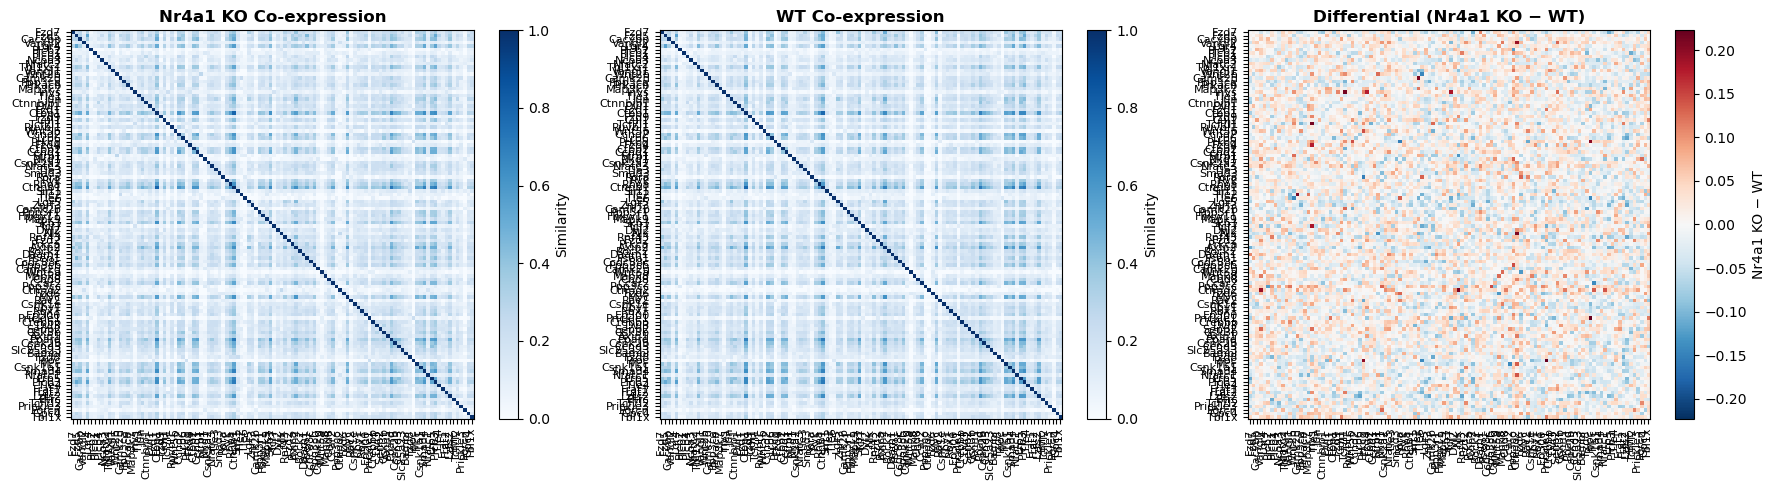

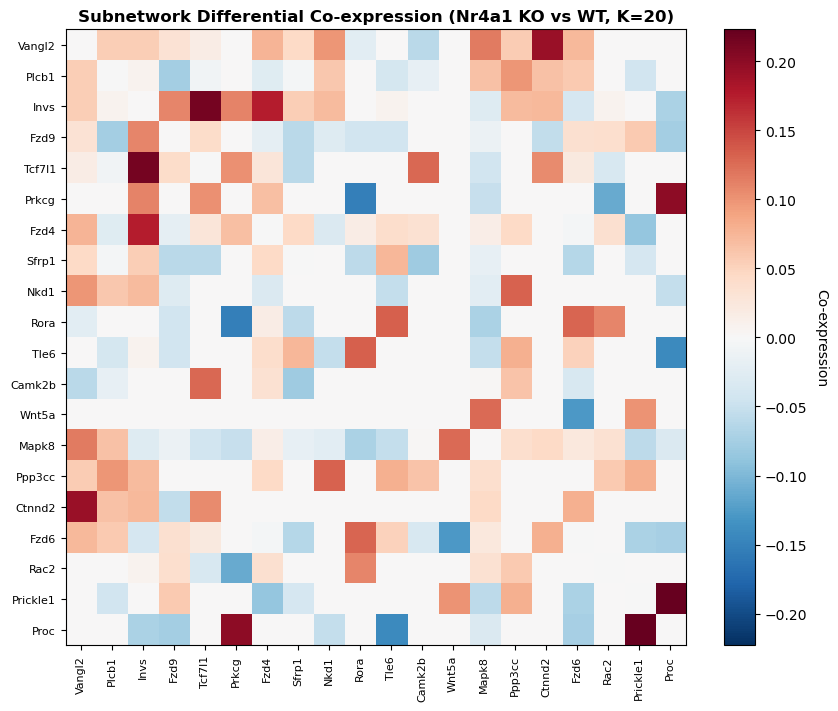

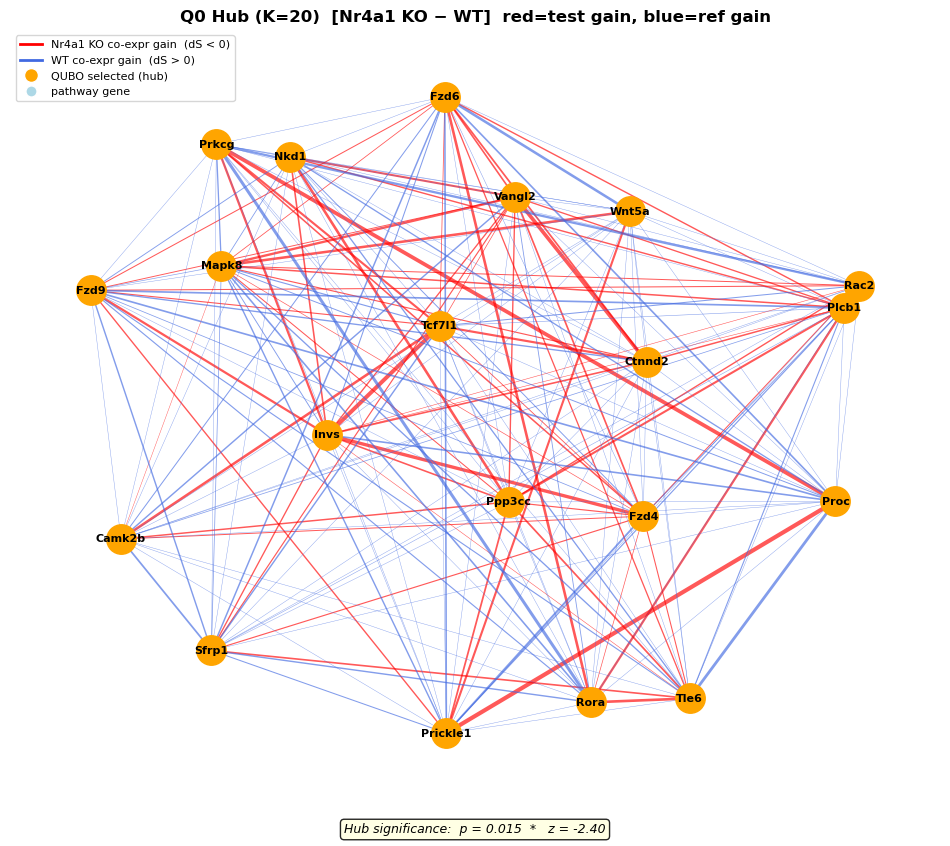

In [15]:
from qubo_dr.pipeline import run_pipeline

# ── cell_potency split by condition (for the Vdiff linear term) ─────────────
# Pass None to both if you want to skip the cell-state term
#idx_A = np.where(batch_id == TEST_LABEL)[0].tolist()
#idx_B = np.where(batch_id == REFERENCE_LABEL)[0].tolist()

batch_id2 = np.asarray(batch_id, dtype=str)
idx_A = batch_id2 == TEST_LABEL
idx_B = batch_id2 == REFERENCE_LABEL

results = run_pipeline(
    X                       = X,
    g                       = g,
    batch_id                = batch_id,
    test_label              = TEST_LABEL,
    reference_label         = REFERENCE_LABEL,
    pathway_name            = PATHWAY_NAME,
    library                 = LIBRARY,
    K                       = K,
    cell_state              = cell_potency,    # remove if not using cell_potency
    penalty_scale           = 2,
    num_reads               = 1000,
    solver                  = 'sd',    # 'sd'=fast greedy  |  'sa'=simulated annealing
    plotit                  = True,
    run_perm_test           = True,
    n_perm                  = 200,
    outfile                 = 'qubo_genes_nr4a1_wnt.txt',
)

print("\n── Selected hub genes ──")
print(results['sub_g_net'])
print(f"\nHub permutation test:  p = {results['hub_perm_result']['pval']:.4f}  "
      f"z = {results['hub_perm_result']['zscore']:.2f}  "
      f"{results['hub_perm_result']['significance_label']}")

---
## Debug — Step-by-step pipeline outside the wrapper

Run these cells **instead of** (or after) the pipeline call above to inspect every intermediate variable — SA, SB, dS (Q0), Q1, Q, the K×K subnetworks, and all plots.  
Each cell prints a sanity-check block so you can see exactly which step produces unexpected values.

### D1 — Imports

In [16]:
import numpy as np
import matplotlib.pyplot as plt

from qubo_dr.preprocess  import subset_by_condition, compute_gene_similarity, compute_differential
from qubo_dr.graph       import build_mnn_adjacency
from qubo_dr.pathway     import get_pathway_genes
from qubo_dr.qubo        import assemble_qubo_matrix, solve_qubo_simulated_annealing, extract_subnetwork
from qubo_dr.plot        import plot_coexpr_heatmap, plot_gene_network, plot_condition_heatmaps
from qubo_dr.permutation import test_differential_hub

# X, g, batch_id, TEST_LABEL, REFERENCE_LABEL, PATHWAY_NAME, LIBRARY, K
# must already be defined from the data prep cell above
print("Imports OK")

Imports OK


### D2 — Pathway gene lookup and subset to pathway genes

In [17]:
pathway_genelist = get_pathway_genes(pathway_name=PATHWAY_NAME, library=LIBRARY)
print(f"Pathway genes fetched from Enrichr: {len(pathway_genelist)}")

# Subset X to only pathway genes
g_upper  = np.array([gi.upper() for gi in g])
gl_upper = set(gi.upper() for gi in pathway_genelist)
mask     = np.isin(g_upper, list(gl_upper))
X_path   = X[mask, :]
g_path   = [g[i] for i in np.where(mask)[0]]
G        = X_path.shape[0]

print(f"Pathway genes found in data: {G} / {len(pathway_genelist)}")
print(f"X_path shape (pathway genes × cells): {X_path.shape}")
print(f"First 8 pathway genes in data: {g_path[:8]}")

# Expected: G > 0, and X_path should NOT be all zeros
assert G > 0, "No pathway genes found — check gene name format (case, Ensembl vs symbol)"
print(f"\nX_path  non-zero entries: {np.count_nonzero(X_path)} / {X_path.size}  "
      f"({100*np.count_nonzero(X_path)/X_path.size:.1f}%)")

  Found 'WNT SIGNALING PATHWAY'
  Library: [KEGG_2026]  |  Genes: 170
Pathway genes fetched from Enrichr: 170
Pathway genes found in data: 110 / 170
X_path shape (pathway genes × cells): (110, 2817)
First 8 pathway genes in data: ['Fzd7', 'Fzd5', 'Cacybp', 'Vangl2', 'Lgr4', 'Plcb2', 'Plcb1', 'Plcb4']

X_path  non-zero entries: 55947 / 309870  (18.1%)


### D3 — Split by condition and inspect both halves

In [17]:
X_A, idx_A = subset_by_condition(X_path, np.arange(X_path.shape[1]), batch_id, TEST_LABEL)
X_B, idx_B = subset_by_condition(X_path, np.arange(X_path.shape[1]), batch_id, REFERENCE_LABEL)

print(f"X_A  ({TEST_LABEL})       shape: {X_A.shape}")
print(f"X_B  ({REFERENCE_LABEL})  shape: {X_B.shape}")
print(f"\nX_A  min={X_A.min():.4f}  max={X_A.max():.4f}  mean={X_A.mean():.4f}")
print(f"X_B  min={X_B.min():.4f}  max={X_B.max():.4f}  mean={X_B.mean():.4f}")
print(f"\nX_A non-zero: {np.count_nonzero(X_A)} ({100*np.count_nonzero(X_A)/X_A.size:.1f}%)")
print(f"X_B non-zero: {np.count_nonzero(X_B)} ({100*np.count_nonzero(X_B)/X_B.size:.1f}%)")

# cell_potency per condition (only needed if passing cs_A / cs_B to pipeline)
cs_A_dbg = cell_potency[idx_A]
cs_B_dbg = cell_potency[idx_B]
print(f"\ncell_potency  {TEST_LABEL}: mean={cs_A_dbg.mean():.3f}  std={cs_A_dbg.std():.3f}")
print(f"cell_potency  {REFERENCE_LABEL}: mean={cs_B_dbg.mean():.3f}  std={cs_B_dbg.std():.3f}")

X_A  (Nr4a1 KO)       shape: (110, 1111)
X_B  (WT)  shape: (110, 1706)

X_A  min=0.0000  max=2.1884  mean=0.1320
X_B  min=0.0000  max=2.4832  mean=0.1340

X_A non-zero: 21929 (17.9%)
X_B non-zero: 34018 (18.1%)

cell_potency  Nr4a1 KO: mean=0.107  std=0.033
cell_potency  WT: mean=0.103  std=0.033


### D4 — Gram matrices SA and SB (cosine similarity)

In [18]:
SA, XA_norm = compute_gene_similarity(X_A)   # S_A = X_A_norm · X_A_norm^T
SB, XB_norm = compute_gene_similarity(X_B)   # S_B = X_B_norm · X_B_norm^T

print(f"SA  shape={SA.shape}  min={SA.min():.4f}  max={SA.max():.4f}  mean={SA.mean():.4f}")
print(f"SB  shape={SB.shape}  min={SB.min():.4f}  max={SB.max():.4f}  mean={SB.mean():.4f}")

# Diagonal = cosine self-similarity = 1 for expressed genes, 0 for silenced genes
diag_A = np.diag(SA)
diag_B = np.diag(SB)
print(f"\nSA diagonal:  min={diag_A.min():.3f}  max={diag_A.max():.3f}  "
      f"zeros={int((diag_A == 0).sum())} genes silenced in {TEST_LABEL}")
print(f"SB diagonal:  min={diag_B.min():.3f}  max={diag_B.max():.3f}  "
      f"zeros={int((diag_B == 0).sum())} genes silenced in {REFERENCE_LABEL}")

# Off-diagonal: values in [0, 1] — how similar the co-expression profiles are
off_A = SA[np.triu_indices(G, k=1)]
off_B = SB[np.triu_indices(G, k=1)]
print(f"\nSA off-diag:  mean={off_A.mean():.4f}  std={off_A.std():.4f}")
print(f"SB off-diag:  mean={off_B.mean():.4f}  std={off_B.std():.4f}")

# If SA ≈ SB here, dS will be flat — investigate batch_id labels
print(f"\nSA vs SB mean difference (off-diag): {np.abs(off_A - off_B).mean():.4f}  "
      f"(0 = identical conditions)")

SA  shape=(110, 110)  min=0.0000  max=1.0000  mean=0.1546
SB  shape=(110, 110)  min=0.0000  max=1.0000  mean=0.1533

SA diagonal:  min=1.000  max=1.000  zeros=0 genes silenced in Nr4a1 KO
SB diagonal:  min=1.000  max=1.000  zeros=0 genes silenced in WT

SA off-diag:  mean=0.1469  std=0.1126
SB off-diag:  mean=0.1455  std=0.1153

SA vs SB mean difference (off-diag): 0.0305  (0 = identical conditions)


### D5 — dS = Q0 = S_B − S_A   (the raw biological signal)

In [19]:
dS, Vdiff = compute_differential(
    SB, SA,                    # positional: Xref2norm=SB (reference), Xtest2norm=SA (test)
    Xref_norm=XB_norm,         # L2-normalised reference expression  (genes × cells_B)
    Xtest_norm=XA_norm,        # L2-normalised test expression       (genes × cells_A)
    cs_ref=cs_B_dbg,           # cell-state scalar for reference cells (cell_potency)
    cs_test=cs_A_dbg,          # cell-state scalar for test cells
    # ── remove cs_ref / cs_test lines if skipping the Vdiff term ──────────
)
# Q0 = dS by definition
Q0 = dS.copy()

print(f"dS (= Q0)  shape={dS.shape}")
print(f"  min={dS.min():.4f}  max={dS.max():.4f}  "
      f"mean={dS.mean():.4f}  std={dS.std():.4f}")

# ── Sign breakdown ─────────────────────────────────────────────────────────
off_idx  = np.triu_indices(G, k=1)
off_diff = dS[off_idx]
n_neg    = (off_diff < 0).sum()
n_pos    = (off_diff > 0).sum()
print(f"\nOff-diagonal:  {n_neg} negative ({100*n_neg/len(off_diff):.1f}%)  "
      f"= {TEST_LABEL} co-expr gain  (red edges)")
print(f"               {n_pos} positive ({100*n_pos/len(off_diff):.1f}%)  "
      f"= {REFERENCE_LABEL} co-expr gain  (blue edges)")

# ── Vdiff ──────────────────────────────────────────────────────────────────
print(f"\nVdiff  min={Vdiff.min():.4f}  max={Vdiff.max():.4f}  "
      f"mean={Vdiff.mean():.4f}  (all-zero = no cell-state term)")

# ── Critical assertion ─────────────────────────────────────────────────────
assert dS.std() > 1e-8, \
    "dS is flat (std≈0) — SA and SB are identical. " \
    "Check that TEST_LABEL and REFERENCE_LABEL match the actual strings in batch_id."
print("\n✓ dS is non-trivial — ready for QUBO")

Xdiff (= Q0)  shape=(110, 110)
  min=-0.2230  max=0.1529  mean=-0.0014  std=0.0391

Off-diagonal:  2956 negative (49.3%)  = Nr4a1 KO co-expr gain  (red edges)
               2841 positive (47.4%)  = WT co-expr gain  (blue edges)

Vdiff  min=-0.0597  max=0.0774  mean=0.0027  (all-zero = no cell-state term)

✓ Xdiff is non-trivial — ready for QUBO


### D6 — Plot SA / SB / dS heatmaps (full pathway, before QUBO)

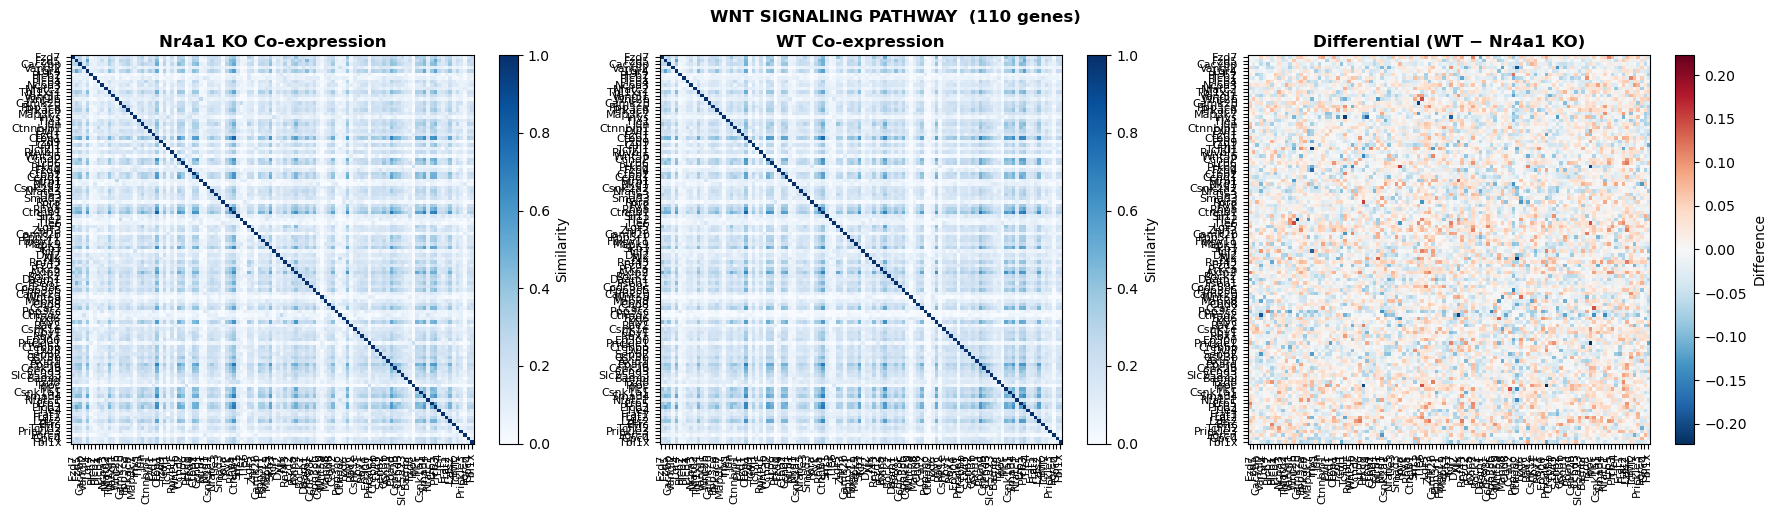

Top 10 most-changed genes (by row-sum |Xdiff|):
  Ppp3cc        total |Xdiff| = 4.7707
  Ctnnd2        total |Xdiff| = 4.3301
  Rnf43         total |Xdiff| = 4.2659
  Prickle1      total |Xdiff| = 4.0801
  Cby1          total |Xdiff| = 4.0399
  Ppp3ca        total |Xdiff| = 3.9720
  Invs          total |Xdiff| = 3.9480
  Nfatc3        total |Xdiff| = 3.9433
  Vangl1        total |Xdiff| = 3.9031
  Frat2         total |Xdiff| = 3.9026


In [20]:
fig = plot_condition_heatmaps(
    SA, SB, dS, g_path,
    test_label=TEST_LABEL,
    reference_label=REFERENCE_LABEL,
)
plt.suptitle(f"{PATHWAY_NAME}  ({G} genes)", y=1.02, fontweight='bold')
plt.show()

# Quick per-gene view: which genes differ most between conditions?
gene_diff = np.abs(dS).sum(axis=1)   # total absolute differential per gene
top10_idx = np.argsort(gene_diff)[-10:][::-1]
print("Top 10 most-changed genes (by row-sum |dS|):")
for i in top10_idx:
    print(f"  {g_path[i]:12s}  total |dS| = {gene_diff[i]:.4f}")

### D7 — MNN adjacency and QUBO assembly → Q0, Q1, Q

In [25]:
A_mnn_test = build_mnn_adjacency(X_A, method='mnn', K=30, n_svd=50)
A_mnn_ref = build_mnn_adjacency(X_B, method='mnn', K=30, n_svd=50)

print(f"A_mnn_test  nnz={np.count_nonzero(A_mnn_test.toarray())}  "
      f"min={A_mnn_test.min():.4f}  max={A_mnn_test.max():.4f}")
print(f"A_mnn_ref  nnz={np.count_nonzero(A_mnn_ref.toarray())}  "
      f"min={A_mnn_ref.min():.4f}  max={A_mnn_ref.max():.4f}")

# assemble_qubo_matrix returns (Q, Q1, Q0, P)
Q, Q1, Q0_out, P = assemble_qubo_matrix(
    dS, Vdiff, A_mnn_test, A_mnn_ref, K,
    Xnet_target=None,     # no pathway prior (pure pathway analysis)
    penalty_scale=2,
)

print(f"\nQ0  min={Q0_out.min():.4f}  max={Q0_out.max():.4f}  std={Q0_out.std():.4f}")
print(f"Q1  min={Q1.min():.4f}  max={Q1.max():.4f}  std={Q1.std():.4f}")
print(f"Q   min={Q.min():.4f}   max={Q.max():.4f}   std={Q.std():.4f}")
print(f"Penalty P = {P:.4f}")

# Q0 must match dS exactly
assert np.allclose(Q0_out, dS), "Q0 != dS — something is wrong in assemble_qubo_matrix"
# Q1 must differ from Q0 (MNN adjacency should modify it)
assert not np.allclose(Q0_out, Q1), "Q1 == Q0 — MNN had zero effect (check A_mnn_test / A_mnn_ref)"
print("\n✓ Q0 == dS  ✓ Q1 != Q0  ✓ QUBO matrices look healthy")

Xmnn_A  nnz=966  min=0.0000  max=1.0000
Xmnn_B  nnz=1008  min=0.0000  max=1.0000
  Penalty (spectral): ||Q1||_2=57.8416 → P=115.6833 (scale=2)
QUBO assembled: 110×110 | penalty P=115.6833 | K=20

Q0  min=-0.2230  max=0.1529  std=0.0391
Q1  min=-2.2230  max=0.1415  std=0.5295
Q   min=-4511.7077   max=115.8248   std=439.1730
Penalty P = 115.6833

✓ Q0 == Xdiff  ✓ Q1 != Q0  ✓ QUBO matrices look healthy


### D8 — Solve QUBO and extract K×K subnetwork

In [26]:
selected_idx, best_energy, _ = solve_qubo_simulated_annealing(
    Q, num_reads=1000, seed=42, solver='sd')

n_sel     = selected_idx.sum()
sel_int   = np.where(selected_idx)[0]
sub_g     = [g_path[i] for i in sel_int]

print(f"Selected {n_sel} genes  (target K={K})  |  best energy = {best_energy:.4f}")
print(f"\nSelected genes:")
print(sub_g)

# ── Extract K×K submatrices ────────────────────────────────────────────────
sub_Q0, sub_Q1, sub_Qv = extract_subnetwork(dS, Q1, selected_idx)

print(f"\nsub_Q0  (K×K dS)  min={sub_Q0.min():.4f}  max={sub_Q0.max():.4f}  "
      f"std={sub_Q0.std():.4f}")
print(f"sub_Q1  (K×K Q1)     min={sub_Q1.min():.4f}  max={sub_Q1.max():.4f}  "
      f"std={sub_Q1.std():.4f}")
print(f"sub_Qv  (per-gene)   min={sub_Qv.min():.4f}  max={sub_Qv.max():.4f}")

# ── Manual cross-check: extract the same slice by hand ────────────────────
sub_Q0_manual = dS[np.ix_(sel_int, sel_int)]
match = np.allclose(sub_Q0, sub_Q0_manual)
print(f"\nManual extraction matches extract_subnetwork: {match}")
print(f"sub_Q0 non-zero off-diagonal entries: "
      f"{np.count_nonzero(sub_Q0 - np.diag(np.diag(sub_Q0)))}")

Selected 20 genes  (target K=20)  |  best energy = -47038.4108

Selected genes:
['Vangl2', 'Plcb1', 'Wnt2b', 'Invs', 'Tcf7l1', 'Wnt5b', 'Prkcg', 'Fzd4', 'Nkd1', 'Rora', 'Tle2', 'Tle6', 'Mapk8', 'Ppp3cc', 'Ctnnd2', 'Fzd6', 'Rac2', 'Prickle1', 'Proc', 'Porcn']

sub_Q0  (K×K Xdiff)  min=-0.2230  max=0.1529  std=0.0579
sub_Q1  (K×K Q1)     min=-2.2230  max=0.0364  std=0.4410
sub_Qv  (per-gene)   min=37.7596  max=38.7837

Manual extraction matches extract_subnetwork: True
sub_Q0 non-zero off-diagonal entries: 210


### D9 — Hub permutation test

  Hub permutation test: 200 perms, K=20 genes, N=2817 cells…
  E_real=-4.9561  null: mean=0.1443, std=1.8030
  z=-2.83  p=0.0000  ***

E_real     = -4.9561   (energy of selected hub on Xdiff)
Null mean  = 0.1443  ± 1.8030
z-score    = -2.83
p-value    = 0.0000   ***


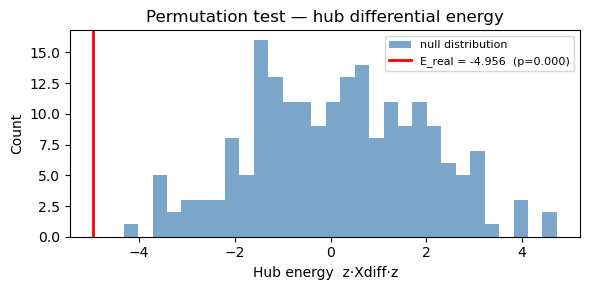

In [27]:
hub = test_differential_hub(
    X_A, X_B, dS, selected_idx,
    n_perm=200, seed=42, verbose=True,
)

print(f"\nE_real     = {hub['E_real']:.4f}   (energy of selected hub on dS)")
print(f"Null mean  = {hub['null_mean']:.4f}  ± {hub['null_std']:.4f}")
print(f"z-score    = {hub['zscore']:.2f}")
print(f"p-value    = {hub['pval']:.4f}   {hub['significance_label']}")

# Quick null distribution plot
fig_p, ax_p = plt.subplots(figsize=(6, 3))
ax_p.hist(hub['E_null'], bins=30, color='steelblue', alpha=0.7, label='null distribution')
ax_p.axvline(hub['E_real'], color='red', lw=2,
             label=f"E_real = {hub['E_real']:.3f}  (p={hub['pval']:.3f})")
ax_p.set_xlabel('Hub energy  z·dS·z')
ax_p.set_ylabel('Count')
ax_p.set_title('Permutation test — hub differential energy')
ax_p.legend(fontsize=8)
plt.tight_layout()
plt.show()

### D10 — Subnetwork heatmap and Q0 / Q1 network plots

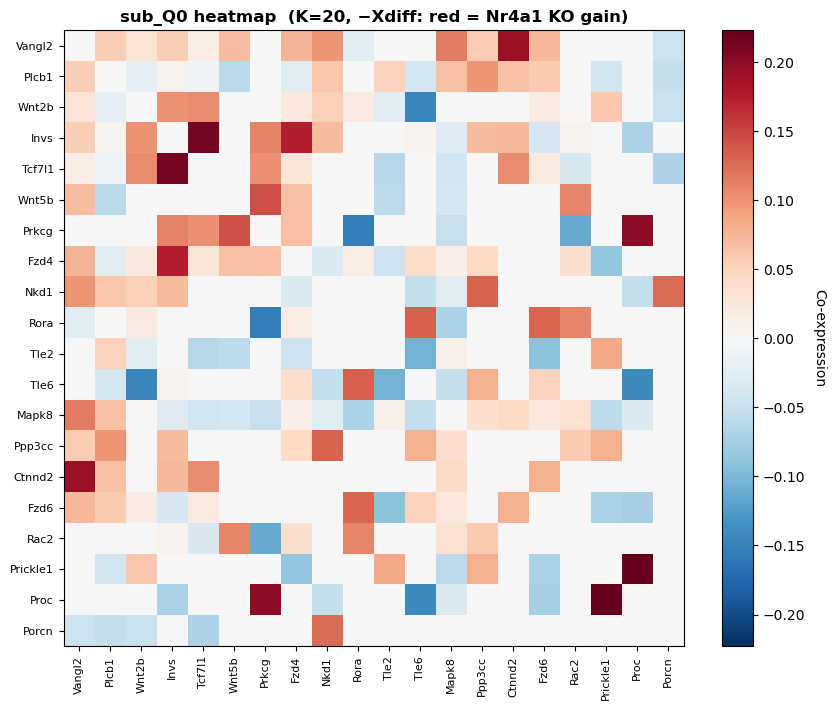

Heatmap matrix:  min=-0.1529  max=0.2230  std=0.0579  (should be non-trivial)


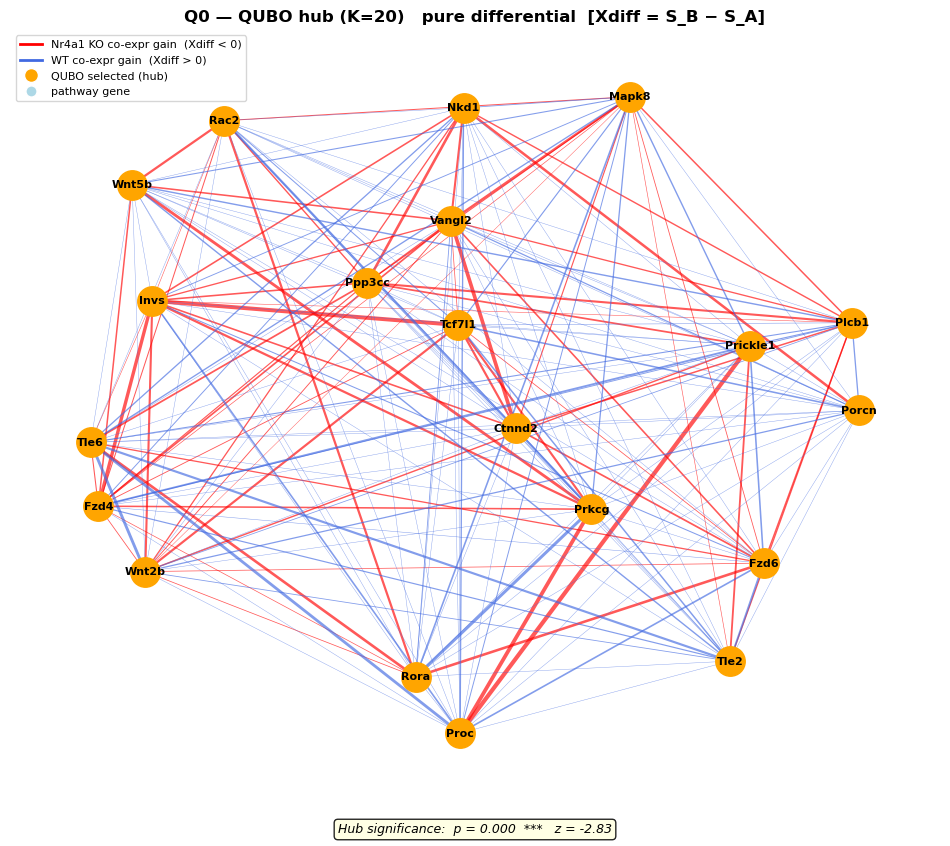

Q0 network edges: 190


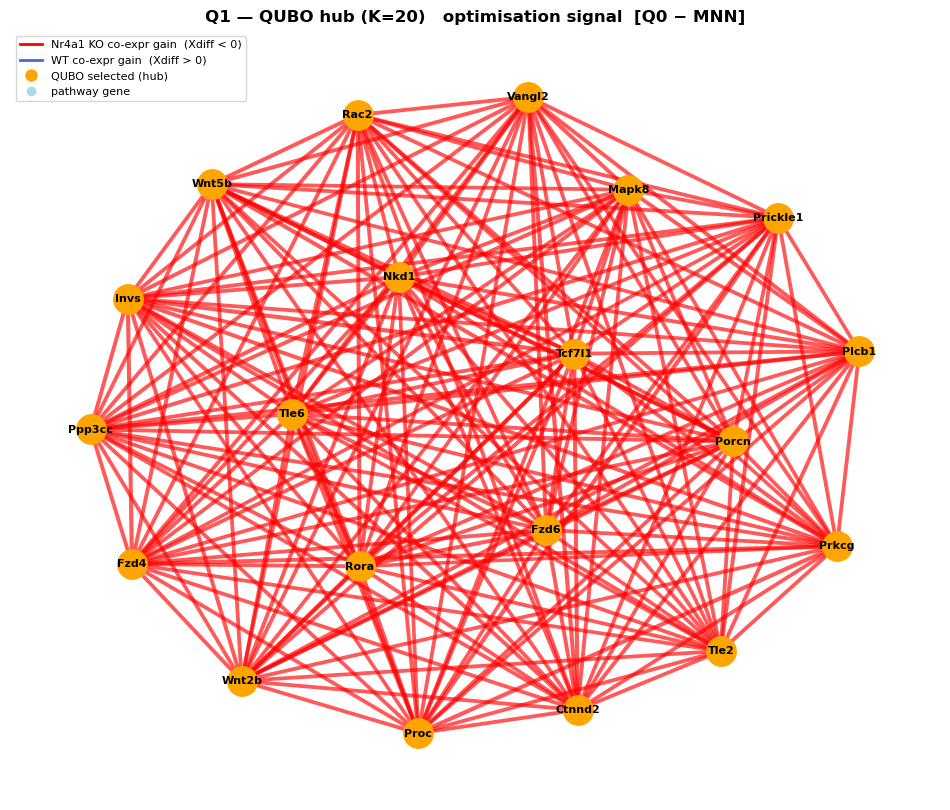

Q1 network edges: 190


In [28]:
all_hub = np.ones(n_sel, dtype=bool)   # all nodes are hub members (orange)

# ── Subnetwork heatmap  (negated: red = disease / test gain) ──────────────
fig_h, ax_h = plot_coexpr_heatmap(
    -sub_Q0, sub_g,
    title=f'sub_Q0 heatmap  (K={n_sel}, −dS: red = {TEST_LABEL} gain)',
)
plt.show()
print(f"Heatmap matrix:  min={(-sub_Q0).min():.4f}  max={(-sub_Q0).max():.4f}  "
      f"std={(-sub_Q0).std():.4f}  (should be non-trivial)")

# ── Q0 network: pure differential  dS = S_B − S_A ─────────────────────
fig_n0, ax_n0, G_nx0 = plot_gene_network(
    sub_Q0, sub_g,
    selected_mask=all_hub,
    top_pct=100,                          # show all edges — K is small
    test_label=TEST_LABEL,
    reference_label=REFERENCE_LABEL,
    perm_pval=hub['pval'],
    perm_zscore=hub['zscore'],
    title=f'Q0 — QUBO hub (K={n_sel})   pure differential  [dS = S_B − S_A]',
)
plt.show()
print(f"Q0 network edges: {G_nx0.number_of_edges()}")

# ── Q1 network: dS − MNN (optimisation landscape) ─────────────────────
fig_n1, ax_n1, G_nx1 = plot_gene_network(
    sub_Q1, sub_g,
    selected_mask=all_hub,
    top_pct=100,
    test_label=TEST_LABEL,
    reference_label=REFERENCE_LABEL,
    title=f'Q1 — QUBO hub (K={n_sel})   optimisation signal  [Q0 − MNN]',
)
plt.show()
print(f"Q1 network edges: {G_nx1.number_of_edges()}")

---
## Step 4 — Hub network visualization with edge filtering

Use `plot_hub_network()` to explore the hub at different levels of edge density.
The function works directly on the `results` dict and offers three modes:

| Parameter | Meaning |
|---|---|
| `top_pct=X` | Show the top X% of edges by \|dS\| strength |
| `edge_threshold=t` | Show edges with \|dS(i,j)\| ≥ t (absolute) |
| `n_sigma=s` | Show edges with \|dS(i,j)\| ≥ s × σ\_edge, where σ\_edge is estimated from the permutation null distribution — **statistically principled** |

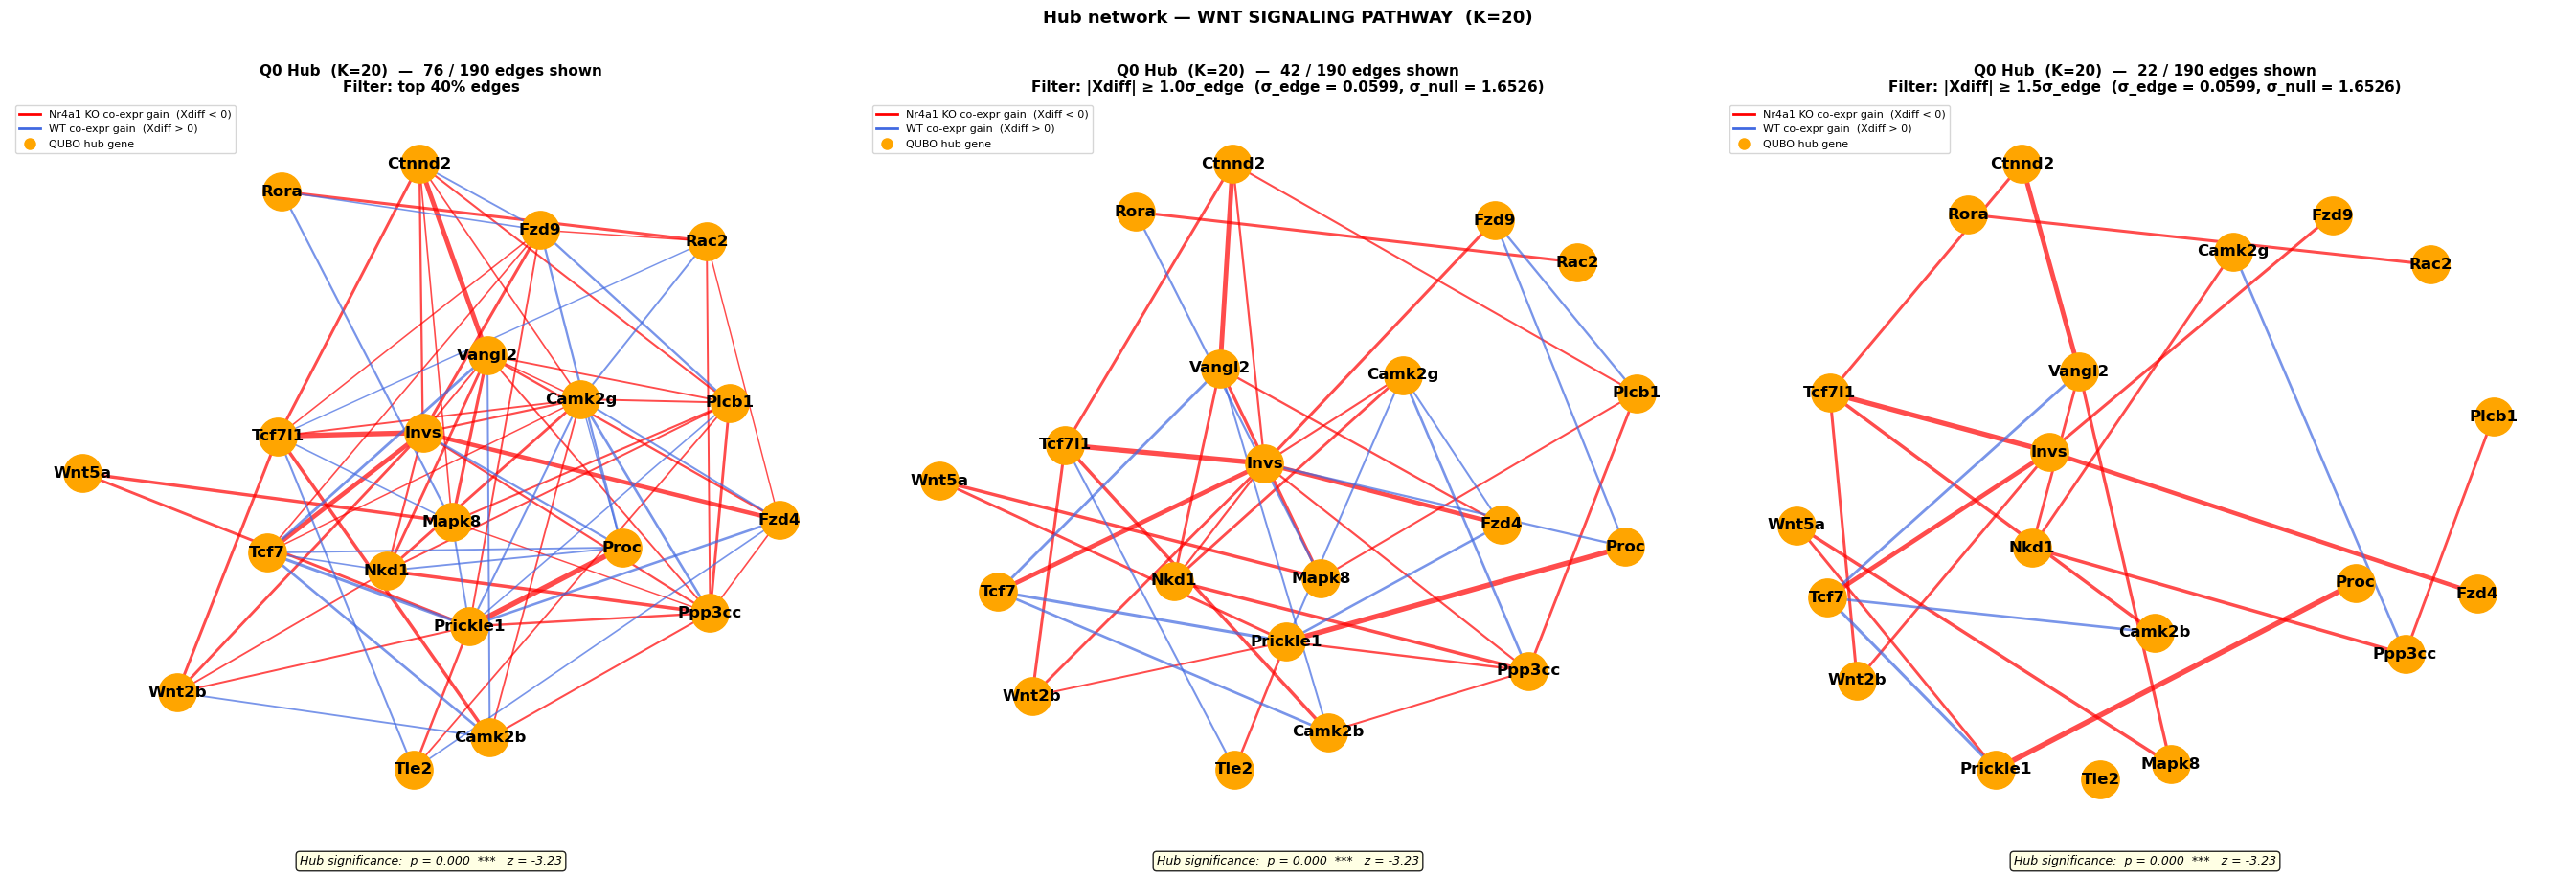

In [29]:
from qubo_dr.plot import plot_hub_network
import matplotlib.pyplot as plt

# ── Three panels: coarse → stat-informed → fine ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(27, 9))

# Panel 1 — top 40 % of hub edges (quick overview)
plot_hub_network(
    results, top_pct=40,
    test_label=TEST_LABEL, reference_label=REFERENCE_LABEL,
    ax=axes[0]
)

# Panel 2 — statistically principled: edges above 1 null-noise σ
#   σ_edge = std(E_null) / (2 × √(K×(K−1)/2))
#   Requires run_perm_test=True in run_pipeline() (already done above)
plot_hub_network(
    results, n_sigma=1.0,
    test_label=TEST_LABEL, reference_label=REFERENCE_LABEL,
    ax=axes[1]
)

# Panel 3 — stricter: 1.5 σ (fewer, strongest edges only)
plot_hub_network(
    results, n_sigma=1.5,
    test_label=TEST_LABEL, reference_label=REFERENCE_LABEL,
    ax=axes[2]
)

plt.suptitle(f'Hub network — {PATHWAY_NAME}  (K={K})',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
